In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio
import seaborn as sns

%matplotlib inline

pd.set_option('display.max_columns', None) 
pd.set_option('display.max_rows', 500) 
pd.set_option('display.expand_frame_repr', False)


# Dataset Exploration

In [28]:
df = pd.read_csv("../data/raw/UNSW_NB15_training-set.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  str    
 3   service            175341 non-null  str    
 4   state              175341 non-null  str    
 5   spkts              175341 non-null  int64  
 6   dpkts              175341 non-null  int64  
 7   sbytes             175341 non-null  int64  
 8   dbytes             175341 non-null  int64  
 9   rate               175341 non-null  float64
 10  sttl               175341 non-null  int64  
 11  dttl               175341 non-null  int64  
 12  sload              175341 non-null  float64
 13  dload              175341 non-null  float64
 14  sloss              175341 non-null  int64  
 15  dloss              175341 non-null  int64  
 16  sinpkt       

In [29]:
df

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,252,254,1.415894e+04,8495.365234,0,0,24.295600,8.375000,30.177547,11.830604,255,621772692,2202533631,255,0.000000,0.000000,0.000000,43,43,0,0,1,0,1,1,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,62,252,8.395112e+03,503571.312500,2,17,49.915000,15.432865,61.426934,1387.778330,255,1417884146,3077387971,255,0.000000,0.000000,0.000000,52,1106,0,0,43,1,1,1,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,62,252,1.572272e+03,60929.230470,1,6,231.875571,102.737203,17179.586860,11420.926230,255,2116150707,2963114973,255,0.111897,0.061458,0.050439,46,824,0,0,7,1,2,1,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,62,252,2.740179e+03,3358.622070,1,3,152.876547,90.235726,259.080172,4991.784669,255,1107119177,1047442890,255,0.000000,0.000000,0.000000,52,64,0,0,1,1,2,1,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,254,252,8.561499e+03,3987.059814,2,1,47.750333,75.659602,2415.837634,115.807000,255,2436137549,1977154190,255,0.128381,0.071147,0.057234,53,45,0,0,43,1,2,2,1,40,0,0,0,2,39,0,Normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175336,175337,0.000009,udp,dns,INT,2,0,114,0,111111.107200,254,0,5.066666e+07,0.000000,0,0,0.009000,0.000000,0.000000,0.000000,0,0,0,0,0.000000,0.000000,0.000000,57,0,0,0,24,2,24,24,13,24,0,0,0,24,24,0,Generic,1
175337,175338,0.505762,tcp,-,FIN,10,8,620,354,33.612649,254,252,8.826286e+03,4903.492188,2,1,54.400111,66.980570,3721.068786,120.177727,255,3518776216,3453092386,255,0.099440,0.036895,0.062545,62,44,0,0,1,1,1,1,1,2,0,0,0,1,1,0,Shellcode,1
175338,175339,0.000009,udp,dns,INT,2,0,114,0,111111.107200,254,0,5.066666e+07,0.000000,0,0,0.009000,0.000000,0.000000,0.000000,0,0,0,0,0.000000,0.000000,0.000000,57,0,0,0,12,2,3,3,3,13,0,0,0,3,12,0,Generic,1
175339,175340,0.000009,udp,dns,INT,2,0,114,0,111111.107200,254,0,5.066666e+07,0.000000,0,0,0.009000,0.000000,0.000000,0.000000,0,0,0,0,0.000000,0.000000,0.000000,57,0,0,0,30,2,30,30,14,30,0,0,0,30,30,0,Generic,1


First check for duplicates

In [30]:
n_before = len(df)
df = df.drop_duplicates(subset=[c for c in df.columns if c != 'id']).reset_index(drop=True)
print(f"Duplicate rows removed: {n_before - len(df)}")
print(f"Remaining rows: {len(df)}")

Duplicate rows removed: 67601
Remaining rows: 107740


In [31]:
df['label'].value_counts()

label
1    55850
0    51890
Name: count, dtype: int64

This dataset is almost balanced, with 51.8% of training data being labelled as attack (1) vs 48.2% being labelled as normal (0).

Correlation Heatmap Analysis, excluding irrelevant columns (id, label, stcpb, dtcpb) 

In [32]:
num_cols_eda = df.select_dtypes(include='number').columns.difference(['id', 'label', 'stcpb', 'dtcpb']).tolist()

corr_matrix = df[num_cols_eda].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [(col, row, round(upper.loc[row, col], 3))
             for col in upper.columns for row in upper.index
             if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > 0.9]
high_corr.sort(key=lambda x: x[2], reverse=True)

print(f"Feature pairs with correlation > 0.9: {len(high_corr)}")
for a, b, v in high_corr:
    print(f"  {a:30s} <-> {b:30s}  {v}")

Feature pairs with correlation > 0.9: 12
  is_ftp_login                   <-> ct_ftp_cmd                      1.0
  dloss                          <-> dbytes                          0.997
  sloss                          <-> sbytes                          0.997
  swin                           <-> dwin                            0.987
  dpkts                          <-> dloss                           0.978
  spkts                          <-> sloss                           0.974
  dpkts                          <-> dbytes                          0.972
  spkts                          <-> sbytes                          0.966
  sinpkt                         <-> is_sm_ips_ports                 0.946
  tcprtt                         <-> synack                          0.942
  tcprtt                         <-> ackdat                          0.932
  ct_srv_src                     <-> ct_srv_dst                      0.913


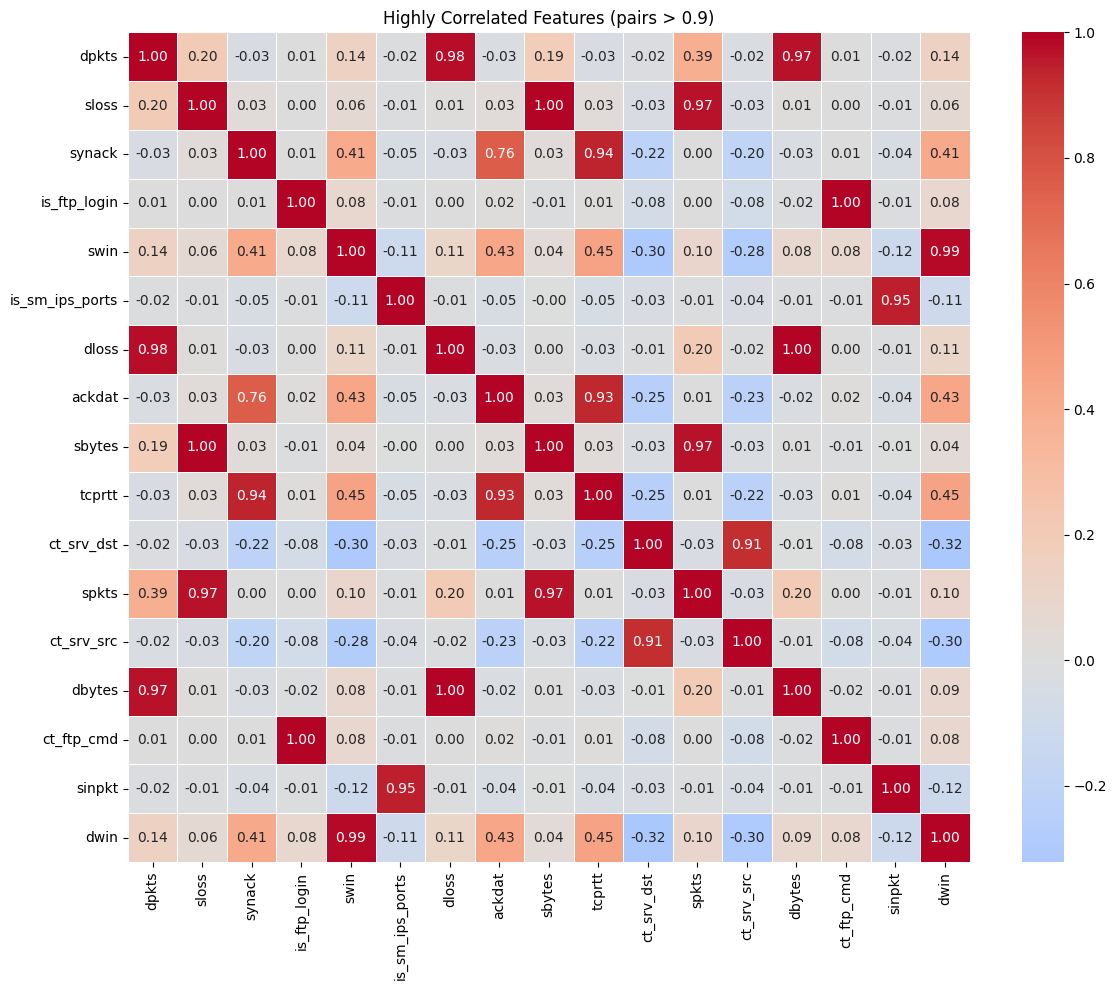

In [33]:
if high_corr:
    corr_features = list(set([f for a, b, _ in high_corr for f in (a, b)]))
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(df[corr_features].corr(), annot=True, fmt='.2f', cmap='coolwarm',
                center=0, ax=ax, linewidths=0.5)
    ax.set_title('Highly Correlated Features (pairs > 0.9)')
    plt.tight_layout()
    plt.show()
else:
    print("No feature pairs with correlation > 0.9")

## Feature Engineering
Let's conduct an EDA on our features to determine any pre-processing that needs to be done within our dataset, as well as if there are any features to exclude or modify to train our models.

First, drop the irrelevant columns being 'id' and 'attack_cat' as we do not need the id nor are we classifying the attack type (a different problem). Additionally, drop the columns 'stcpb' and 'dtcpb' as they are random TCP sequence numbers and will not contribute to the predictions.

In [34]:
df.drop(['id', 'attack_cat', 'stcpb', 'dtcpb'],axis=1,inplace=True)

Now get categorical vs numerical features

In [35]:
cat_cols = df.select_dtypes(include=['str']).columns.tolist()
num_cols = df.select_dtypes(include='number').columns.difference(['label']).tolist()

print(f"Categorical features ({len(cat_cols)}): {cat_cols}")
print(f"Numerical features  ({len(num_cols)}): {num_cols}")

Categorical features (3): ['proto', 'service', 'state']
Numerical features  (37): ['ackdat', 'ct_dst_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'ct_flw_http_mthd', 'ct_ftp_cmd', 'ct_src_dport_ltm', 'ct_src_ltm', 'ct_srv_dst', 'ct_srv_src', 'ct_state_ttl', 'dbytes', 'dinpkt', 'djit', 'dload', 'dloss', 'dmean', 'dpkts', 'dttl', 'dur', 'dwin', 'is_ftp_login', 'is_sm_ips_ports', 'rate', 'response_body_len', 'sbytes', 'sinpkt', 'sjit', 'sload', 'sloss', 'smean', 'spkts', 'sttl', 'swin', 'synack', 'tcprtt', 'trans_depth']


### Categorical Features — Unique counts & distributions

In [36]:
for col in cat_cols:
    vc = df[col].value_counts()
    print(f"\n{col}  ({vc.shape[0]} unique values)")
    print(vc.to_string())


proto  (133 unique values)
proto
tcp            76293
udp            23027
unas            2582
ospf             775
arp              633
sctp             316
any               93
gre               63
rsvp              62
ipv6              59
sun-nd            57
swipe             57
sep               57
mobile            57
pim               57
ib                32
ddp               31
ipv6-frag         31
cftp              31
wsn               31
pvp               31
wb-expak          31
mtp               31
pri-enc           31
sat-mon           31
cphb              31
iso-ip            31
xtp               31
il                31
mfe-nsp           31
3pc               31
ipv6-route        31
idrp              31
bna               31
kryptolan         31
cpnx              31
wb-mon            31
vmtp              31
dgp               31
eigrp             31
ax.25             31
gmtp              31
pnni              31
pgm               31
idpr-cmtp         31
zero              31


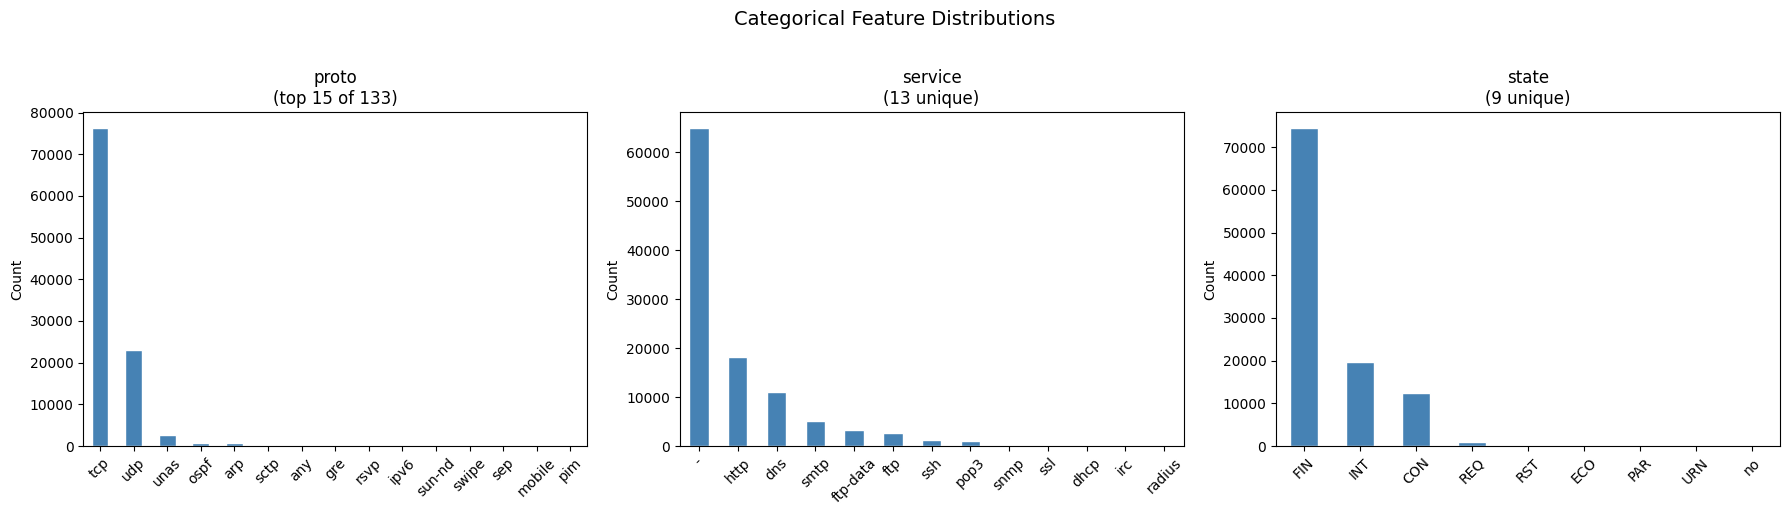

In [37]:
fig, axes = plt.subplots(1, len(cat_cols), figsize=(6 * len(cat_cols), 5))

for ax, col in zip(axes, cat_cols):
    vc = df[col].value_counts()
    # Cap at top 15 as proto has 131 values
    if len(vc) > 15:
        vc = vc.head(15)
        ax.set_title(f'{col}\n(top 15 of {df[col].nunique()})')
    else:
        ax.set_title(f'{col}\n({len(vc)} unique)')
    vc.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Categorical Feature Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Numerical Features

In [38]:
stats = df[num_cols].describe().T[['min', 'max', 'mean', 'std']]
stats['range'] = stats['max'] - stats['min']
stats.sort_values('range', ascending=False).style.format({
    'min':   '{:,.2f}',
    'max':   '{:,.2f}',
    'mean':  '{:,.2f}',
    'std':   '{:,.2f}',
    'range': '{:,.2f}',
})

,min,max,mean,std,range
sload,0.00,"5,988,000,256.00","49,681,174.10","211,406,399.36","5,988,000,256.00"
dload,0.00,"22,422,730.00","1,089,235.62","3,013,780.59","22,422,730.00"
dbytes,0.00,"14,655,550.00","23,732.48","178,620.85","14,655,550.00"
sbytes,28.00,"12,965,233.00","13,825.41","222,634.75","12,965,205.00"
response_body_len,0.00,"6,558,056.00","3,442.63","68,951.63","6,558,056.00"
sjit,0.00,"1,460,480.02","5,440.63","40,656.34","1,460,480.02"
rate,0.00,"1,000,000.00","38,690.93","116,631.81","1,000,000.00"
djit,0.00,"289,388.27",822.82,"4,806.70","289,388.27"
sinpkt,0.00,"84,371.50",433.20,"4,423.51","84,371.50"
dinpkt,0.00,"56,716.82",106.29,"1,089.29","56,716.82"


## Preprocessing

### Categorical Variables

We conduct preprocessing based on the results of the EDA above. There are three categorical variables: proto, service, and state. For proto, we can see that only 6 out of its 131 unique categories/values have counts of at least 100 in our dataset of 82 322. To prevent falling under the curse of dimensionality and unnessecary complexity when training our different models, we have made the choice to combine all other categories under one new category named "other", to reduce our unique values from 131 to 7. 

This is the same for the service column, where ...

And for state ..

In [39]:
from sklearn.preprocessing import StandardScaler

proto_filter   = ['tcp', 'udp', 'unas', 'arp', 'ospf', 'sctp']
service_filter = ['-', 'dns', 'http', 'smtp', 'ftp', 'ftp-data', 'ssh', 'pop3']
state_filter  = ['FIN', 'INT', 'CON', 'REQ']

df['proto_filtered']   = df['proto'].where(df['proto'].isin(proto_filter), other='other')
df['service_filtered'] = df['service'].where(df['service'].isin(service_filter), other='other')
df['state_filtered']   = df['state'].where(df['state'].isin(state_filter), other='other')

proto_ohe   = pd.get_dummies(df['proto_filtered'],   prefix='proto')
service_ohe = pd.get_dummies(df['service_filtered'], prefix='service')
state_ohe   = pd.get_dummies(df['state_filtered'],   prefix='state')

ohe_cols = proto_ohe.columns.tolist() + service_ohe.columns.tolist() + state_ohe.columns.tolist()

df = pd.concat([df, proto_ohe, service_ohe, state_ohe], axis=1)

In [40]:
df.columns

Index(['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss',
       'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'dwin', 'tcprtt', 'synack',
       'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len',
       'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm',
       'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd',
       'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports',
       'label', 'proto_filtered', 'service_filtered', 'state_filtered',
       'proto_arp', 'proto_ospf', 'proto_other', 'proto_sctp', 'proto_tcp',
       'proto_udp', 'proto_unas', 'service_-', 'service_dns', 'service_ftp',
       'service_ftp-data', 'service_http', 'service_other', 'service_pop3',
       'service_smtp', 'service_ssh', 'state_CON', 'state_FIN', 'state_INT',
       'state_REQ', 'state_other'],
      dtype='str')

### Numerical Features

Apply StandardScaler to all numerical columns, with scaled columns being added with a _scaled suffix so originals are preserved.

Additionally, there are multiple columns which are right skewed, as shown from the numerical column chart above. We use a log transformation on these columns to handle the skewness so the distribution appears more normal.

In [41]:
skewed_cols = [
    'sload', 'dload', 'sbytes', 'dbytes', 'sjit', 'djit',
    'rate', 'sinpkt', 'dinpkt', 'spkts', 'dpkts',
    'sloss', 'dloss', 'response_body_len'
]
non_skewed_cols = [c for c in num_cols if c not in skewed_cols]

for col in skewed_cols:
    df[f'{col}_log'] = np.log1p(df[col])

log_cols = [f'{col}_log' for col in skewed_cols]

scaler = StandardScaler()
cols_to_scale = log_cols + non_skewed_cols
scaled_values = scaler.fit_transform(df[cols_to_scale])
scaled_cols = [f'{c}_scaled' for c in cols_to_scale]
df = pd.concat([df, pd.DataFrame(scaled_values, columns=scaled_cols, index=df.index)], axis=1)

In [42]:
df

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label,proto_filtered,service_filtered,state_filtered,proto_arp,proto_ospf,proto_other,proto_sctp,proto_tcp,proto_udp,proto_unas,service_-,service_dns,service_ftp,service_ftp-data,service_http,service_other,service_pop3,service_smtp,service_ssh,state_CON,state_FIN,state_INT,state_REQ,state_other,sload_log,dload_log,sbytes_log,dbytes_log,sjit_log,djit_log,rate_log,sinpkt_log,dinpkt_log,spkts_log,dpkts_log,sloss_log,dloss_log,response_body_len_log,sload_log_scaled,dload_log_scaled,sbytes_log_scaled,dbytes_log_scaled,sjit_log_scaled,djit_log_scaled,rate_log_scaled,sinpkt_log_scaled,dinpkt_log_scaled,spkts_log_scaled,dpkts_log_scaled,sloss_log_scaled,dloss_log_scaled,response_body_len_log_scaled,ackdat_scaled,ct_dst_ltm_scaled,ct_dst_sport_ltm_scaled,ct_dst_src_ltm_scaled,ct_flw_http_mthd_scaled,ct_ftp_cmd_scaled,ct_src_dport_ltm_scaled,ct_src_ltm_scaled,ct_srv_dst_scaled,ct_srv_src_scaled,ct_state_ttl_scaled,dmean_scaled,dttl_scaled,dur_scaled,dwin_scaled,is_ftp_login_scaled,is_sm_ips_ports_scaled,smean_scaled,sttl_scaled,swin_scaled,synack_scaled,tcprtt_scaled,trans_depth_scaled
0,0.121478,tcp,-,FIN,6,4,258,172,74.087490,252,254,14158.942380,8495.365234,0,0,24.295600,8.375000,30.177547,11.830604,255,255,0.000000,0.000000,0.000000,43,43,0,0,1,0,1,1,1,1,0,0,0,1,1,0,0,tcp,-,FIN,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,9.558172,9.047394,5.556828,5.153292,3.439698,2.551833,4.318654,3.230630,2.238047,1.945910,1.609438,0.000000,0.000000,0.0,-0.678199,0.045446,-0.897536,-0.239156,-0.473637,-0.320465,-0.513958,0.325025,-0.077090,-0.493102,-0.390662,-1.170558,-0.983356,-0.318039,-0.665578,-0.520096,-0.210847,-0.491429,-0.314421,-0.130326,-0.293919,-0.582585,-0.610714,-0.652616,-0.986783,-0.504350,1.141228,-0.223580,0.65059,-0.130326,-0.071304,-0.517400,1.010875,0.642132,-0.636572,-0.693874,-0.170682
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,62,252,8395.112305,503571.312500,2,17,49.915000,15.432865,61.426934,1387.778330,255,255,0.000000,0.000000,0.000000,52,1106,0,0,43,1,1,1,1,2,0,0,0,1,6,0,0,tcp,-,FIN,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,9.035524,13.129483,6.599870,10.645782,4.133997,7.236180,4.375422,3.930158,2.799283,2.708050,3.663562,1.098612,2.890372,0.0,-0.814506,0.856671,-0.250347,1.354464,-0.285208,1.351290,-0.497422,0.645125,0.184152,0.176372,1.026154,-0.095735,1.377236,-0.318039,-0.665578,-0.520096,-0.210847,-0.328989,-0.314421,-0.130326,-0.293919,-0.582585,0.196045,6.041949,0.140007,2.987843,1.123989,-0.127877,0.65059,-0.130326,-0.071304,-0.481036,-0.752046,0.642132,-0.636572,-0.693874,-0.170682
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,62,252,1572.271851,60929.230470,1,6,231.875571,102.737203,17179.586860,11420.926230,255,255,0.111897,0.061458,0.050439,46,824,0,0,7,1,2,1,1,3,0,0,0,2,6,0,0,tcp,-,FIN,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,7.360913,11.017485,5.899897,9.486987,9.751535,9.343290,2.719330,5.450504,4.641861,2.197225,2.833213,0.693147,1.945910,0.0,-1.251245,0.436958,-0.684668,1.018246,1.239365,2.103278,-0.979831,1.340829,1.041829,-0.272344,0.453428,-0.492420,0.605886,-0.318039,0.415850,-0.272040,-0.210847,-0.166549,-0.314421,-0.130326,-0.293919,-0.382076,0.196045,0.303750,0.140007,2.061410,1.123989,0.048383,0.65059,-0.130326,-0.071304,-0.505279,-0.752046,0.642132,0.585224,0.537300,-0.170682
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,62,252,2740.178955,3358.622070,1,3,152.876547,90.235726,259.080172,4991.784669,255,25

df_full: every column: originals, log-transformed, OHE, scaled, and label  
df_model: for LR & MLP: OHE + log-then-scaled (skewed) + scaled (non-skewed) + label  
df_model_tree: for RF & XGBoost: OHE + raw numerical columns + label (no scaling needed)

In [43]:
df_full = df.copy()
df_model = df[ohe_cols + scaled_cols + ['label']].copy()
df_model_tree = df[ohe_cols + num_cols + ['label']].copy()

print(f"df_full: {df_full.shape}")
print(f"df_model: {df_model.shape}")
print(f"df_model_tree: {df_model_tree.shape}")

df_full: (107740, 116)
df_model: (107740, 59)
df_model_tree: (107740, 59)


In [44]:
df_full

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label,proto_filtered,service_filtered,state_filtered,proto_arp,proto_ospf,proto_other,proto_sctp,proto_tcp,proto_udp,proto_unas,service_-,service_dns,service_ftp,service_ftp-data,service_http,service_other,service_pop3,service_smtp,service_ssh,state_CON,state_FIN,state_INT,state_REQ,state_other,sload_log,dload_log,sbytes_log,dbytes_log,sjit_log,djit_log,rate_log,sinpkt_log,dinpkt_log,spkts_log,dpkts_log,sloss_log,dloss_log,response_body_len_log,sload_log_scaled,dload_log_scaled,sbytes_log_scaled,dbytes_log_scaled,sjit_log_scaled,djit_log_scaled,rate_log_scaled,sinpkt_log_scaled,dinpkt_log_scaled,spkts_log_scaled,dpkts_log_scaled,sloss_log_scaled,dloss_log_scaled,response_body_len_log_scaled,ackdat_scaled,ct_dst_ltm_scaled,ct_dst_sport_ltm_scaled,ct_dst_src_ltm_scaled,ct_flw_http_mthd_scaled,ct_ftp_cmd_scaled,ct_src_dport_ltm_scaled,ct_src_ltm_scaled,ct_srv_dst_scaled,ct_srv_src_scaled,ct_state_ttl_scaled,dmean_scaled,dttl_scaled,dur_scaled,dwin_scaled,is_ftp_login_scaled,is_sm_ips_ports_scaled,smean_scaled,sttl_scaled,swin_scaled,synack_scaled,tcprtt_scaled,trans_depth_scaled
0,0.121478,tcp,-,FIN,6,4,258,172,74.087490,252,254,14158.942380,8495.365234,0,0,24.295600,8.375000,30.177547,11.830604,255,255,0.000000,0.000000,0.000000,43,43,0,0,1,0,1,1,1,1,0,0,0,1,1,0,0,tcp,-,FIN,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,9.558172,9.047394,5.556828,5.153292,3.439698,2.551833,4.318654,3.230630,2.238047,1.945910,1.609438,0.000000,0.000000,0.0,-0.678199,0.045446,-0.897536,-0.239156,-0.473637,-0.320465,-0.513958,0.325025,-0.077090,-0.493102,-0.390662,-1.170558,-0.983356,-0.318039,-0.665578,-0.520096,-0.210847,-0.491429,-0.314421,-0.130326,-0.293919,-0.582585,-0.610714,-0.652616,-0.986783,-0.504350,1.141228,-0.223580,0.65059,-0.130326,-0.071304,-0.517400,1.010875,0.642132,-0.636572,-0.693874,-0.170682
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,62,252,8395.112305,503571.312500,2,17,49.915000,15.432865,61.426934,1387.778330,255,255,0.000000,0.000000,0.000000,52,1106,0,0,43,1,1,1,1,2,0,0,0,1,6,0,0,tcp,-,FIN,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,9.035524,13.129483,6.599870,10.645782,4.133997,7.236180,4.375422,3.930158,2.799283,2.708050,3.663562,1.098612,2.890372,0.0,-0.814506,0.856671,-0.250347,1.354464,-0.285208,1.351290,-0.497422,0.645125,0.184152,0.176372,1.026154,-0.095735,1.377236,-0.318039,-0.665578,-0.520096,-0.210847,-0.328989,-0.314421,-0.130326,-0.293919,-0.582585,0.196045,6.041949,0.140007,2.987843,1.123989,-0.127877,0.65059,-0.130326,-0.071304,-0.481036,-0.752046,0.642132,-0.636572,-0.693874,-0.170682
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,62,252,1572.271851,60929.230470,1,6,231.875571,102.737203,17179.586860,11420.926230,255,255,0.111897,0.061458,0.050439,46,824,0,0,7,1,2,1,1,3,0,0,0,2,6,0,0,tcp,-,FIN,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,7.360913,11.017485,5.899897,9.486987,9.751535,9.343290,2.719330,5.450504,4.641861,2.197225,2.833213,0.693147,1.945910,0.0,-1.251245,0.436958,-0.684668,1.018246,1.239365,2.103278,-0.979831,1.340829,1.041829,-0.272344,0.453428,-0.492420,0.605886,-0.318039,0.415850,-0.272040,-0.210847,-0.166549,-0.314421,-0.130326,-0.293919,-0.382076,0.196045,0.303750,0.140007,2.061410,1.123989,0.048383,0.65059,-0.130326,-0.071304,-0.505279,-0.752046,0.642132,0.585224,0.537300,-0.170682
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,62,252,2740.178955,3358.622070,1,3,152.876547,90.235726,259.080172,4991.784669,255,25

In [45]:
df_model

,proto_arp,proto_ospf,proto_other,proto_sctp,proto_tcp,proto_udp,proto_unas,service_-,service_dns,service_ftp,service_ftp-data,service_http,service_other,service_pop3,service_smtp,service_ssh,state_CON,state_FIN,state_INT,state_REQ,state_other,sload_log_scaled,dload_log_scaled,sbytes_log_scaled,dbytes_log_scaled,sjit_log_scaled,djit_log_scaled,rate_log_scaled,sinpkt_log_scaled,dinpkt_log_scaled,spkts_log_scaled,dpkts_log_scaled,sloss_log_scaled,dloss_log_scaled,response_body_len_log_scaled,ackdat_scaled,ct_dst_ltm_scaled,ct_dst_sport_ltm_scaled,ct_dst_src_ltm_scaled,ct_flw_http_mthd_scaled,ct_ftp_cmd_scaled,ct_src_dport_ltm_scaled,ct_src_ltm_scaled,ct_srv_dst_scaled,ct_srv_src_scaled,ct_state_ttl_scaled,dmean_scaled,dttl_scaled,dur_scaled,dwin_scaled,is_ftp_login_scaled,is_sm_ips_ports_scaled,smean_scaled,sttl_scaled,swin_scaled,synack_scaled,tcprtt_scaled,trans_depth_scaled,label
0,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,-0.678199,0.045446,-0.897536,-0.239156,-0.473637,-0.320465,-0.513958,0.325025,-0.077090,-0.493102,-0.390662,-1.170558,-0.983356,-0.318039,-0.665578,-0.520096,-0.210847,-0.491429,-0.314421,-0.130326,-0.293919,-0.582585,-0.610714,-0.652616,-0.986783,-0.504350,1.141228,-0.223580,0.65059,-0.130326,-0.071304,-0.517400,1.010875,0.642132,-0.636572,-0.693874,-0.170682,0
1,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,-0.814506,0.856671,-0.250347,1.354464,-0.285208,1.351290,-0.497422,0.645125,0.184152,0.176372,1.026154,-0.095735,1.377236,-0.318039,-0.665578,-0.520096,-0.210847,-0.328989,-0.314421,-0.130326,-0.293919,-0.582585,0.196045,6.041949,0.140007,2.987843,1.123989,-0.127877,0.65059,-0.130326,-0.071304,-0.481036,-0.752046,0.642132,-0.636572,-0.693874,-0.170682,0
2,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,-1.251245,0.436958,-0.684668,1.018246,1.239365,2.103278,-0.979831,1.340829,1.041829,-0.272344,0.453428,-0.492420,0.605886,-0.318039,0.415850,-0.272040,-0.210847,-0.166549,-0.314421,-0.130326,-0.293919,-0.382076,0.196045,0.303750,0.140007,2.061410,1.123989,0.048383,0.65059,-0.130326,-0.071304,-0.505279,-0.752046,0.642132,0.585224,0.537300,-0.170682,0
3,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,-1.106441,-0.138935,-0.346980,0.194436,0.102071,1.807944,-0.989456,1.151223,0.982055,0.050670,0.268395,-0.492420,0.148843,-0.318039,-0.665578,-0.272040,-0.210847,-0.166549,-0.314421,7.398544,-0.293919,-0.382076,-0.610714,-0.652616,0.140007,-0.435361,1.123989,0.058980,0.65059,7.398544,-0.071304,-0.481036,-0.752046,0.642132,-0.636572,-0.693874,-0.170682,0
4,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,-0.809388,-0.104858,-0.447414,-0.111080,0.707072,0.467774,-0.741563,0.625245,0.901029,-0.096072,-0.158583,-0.095735,-0.417257,-0.318039,0.561537,-0.272040,-0.210847,5.843741,-0.314421,-0.130326,0.004774,-0.382076,5.520653,6.041949,0.140007,-0.497780,1.123989,-0.164180,0.65059,-0.130326,-0.071304,-0.476995,1.029432,0.642132,0.777844,0.718669,-0.170682,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107735,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,0.107992,0.048180,2.576790,0.489687,0.706681,0.381695,-0.605677,0.358474,0.831861,1.590123,0.867807,2.279444,0.811137,-0.318039,-0.408509,-0.520096,-0.210847,-0.491429,-0.314421,-0.130326,-0.293919,2.826065,-0.610714,-0.652616,0.140007,-0.412364,1.123989,0.101118,0.65059,-0.130326,-0.071304,3.131161,-0.752046,0.642132,-0.0968

In [46]:
df_model.columns

Index(['proto_arp', 'proto_ospf', 'proto_other', 'proto_sctp', 'proto_tcp',
       'proto_udp', 'proto_unas', 'service_-', 'service_dns', 'service_ftp',
       'service_ftp-data', 'service_http', 'service_other', 'service_pop3',
       'service_smtp', 'service_ssh', 'state_CON', 'state_FIN', 'state_INT',
       'state_REQ', 'state_other', 'sload_log_scaled', 'dload_log_scaled',
       'sbytes_log_scaled', 'dbytes_log_scaled', 'sjit_log_scaled',
       'djit_log_scaled', 'rate_log_scaled', 'sinpkt_log_scaled',
       'dinpkt_log_scaled', 'spkts_log_scaled', 'dpkts_log_scaled',
       'sloss_log_scaled', 'dloss_log_scaled', 'response_body_len_log_scaled',
       'ackdat_scaled', 'ct_dst_ltm_scaled', 'ct_dst_sport_ltm_scaled',
       'ct_dst_src_ltm_scaled', 'ct_flw_http_mthd_scaled', 'ct_ftp_cmd_scaled',
       'ct_src_dport_ltm_scaled', 'ct_src_ltm_scaled', 'ct_srv_dst_scaled',
       'ct_srv_src_scaled', 'ct_state_ttl_scaled', 'dmean_scaled',
       'dttl_scaled', 'dur_scaled', 'dwin_s

In [47]:
df_model_tree

,proto_arp,proto_ospf,proto_other,proto_sctp,proto_tcp,proto_udp,proto_unas,service_-,service_dns,service_ftp,service_ftp-data,service_http,service_other,service_pop3,service_smtp,service_ssh,state_CON,state_FIN,state_INT,state_REQ,state_other,ackdat,ct_dst_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,ct_flw_http_mthd,ct_ftp_cmd,ct_src_dport_ltm,ct_src_ltm,ct_srv_dst,ct_srv_src,ct_state_ttl,dbytes,dinpkt,djit,dload,dloss,dmean,dpkts,dttl,dur,dwin,is_ftp_login,is_sm_ips_ports,rate,response_body_len,sbytes,sinpkt,sjit,sload,sloss,smean,spkts,sttl,swin,synack,tcprtt,trans_depth,label
0,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,0.000000,1,1,1,0,0,1,1,1,1,0,172,8.375000,11.830604,8495.365234,0,43,4,254,0.121478,255,0,0,74.087490,0,258,24.295600,30.177547,14158.942380,0,43,6,252,255,0.000000,0.000000,0,0
1,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,0.000000,1,1,2,0,0,1,1,6,43,1,42014,15.432865,1387.778330,503571.312500,17,1106,38,252,0.649902,255,0,0,78.473372,0,734,49.915000,61.426934,8395.112305,2,52,14,62,255,0.000000,0.000000,0,0
2,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,0.050439,2,1,3,0,0,1,2,6,7,1,13186,102.737203,11420.926230,60929.230470,6,824,16,252,1.623129,255,0,0,14.170161,0,364,231.875571,17179.586860,1572.271851,1,46,8,62,255,0.061458,0.111897,0,0
3,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,0.000000,2,1,3,0,1,1,2,1,1,1,770,90.235726,4991.784669,3358.622070,3,64,12,252,1.681642,255,1,0,13.677108,0,628,152.876547,259.080172,2740.178955,1,52,12,62,255,0.000000,0.000000,0,0
4,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,0.057234,2,1,40,0,0,2,2,39,43,1,268,75.659602,115.807000,3987.059814,1,45,6,252,0.449454,255,0,0,33.373826,0,534,47.750333,2415.837634,8561.499023,2,53,10,254,255,0.071147,0.128381,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107735,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,0.011990,1,1,1,0,0,1,18,1,1,1,2132,65.074277,90.773586,8613.029297,8,71,30,252,1.914309,255,0,0,53.805315,0,69997,26.213891,2412.352478,288572.000000,33,946,74,62,255,0.027147,0.039137,0,1
107736,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,0.035197,1,1,1,0,0,1,2,1,1,1,426483,10.914012,1585.622696,914689.812500,167,1254,340,252,3.719110,255,0,0,108.897021,0,3086,57.217077,3358.369752,6539.198730,6,47,66,62,255,0.025596,0.060793,0,1
107737,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,0.037629,1,1,1,0,0,1,7,1,1,1,16684,33.937380,2479.497222,129476.781300,13,556,30,252,0.996503,255,0,0,49.171955,0,942,52.447526,3005.256004,7185.126465,7,47,20,62,255,0.007366,0.044995,0,1
107738,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,0.036566,2,1,2,0,0,1,2,1,1,1,1954,73.691430,112.418070,9586.899414,8,89,22,252,1.557125,255,0,0,31.468251,0,12601,57.671293,3661.213103,62427.871090,11,450,28,62,255,0.008571,0.045137,0,1


In [48]:
df_model_tree.columns

Index(['proto_arp', 'proto_ospf', 'proto_other', 'proto_sctp', 'proto_tcp',
       'proto_udp', 'proto_unas', 'service_-', 'service_dns', 'service_ftp',
       'service_ftp-data', 'service_http', 'service_other', 'service_pop3',
       'service_smtp', 'service_ssh', 'state_CON', 'state_FIN', 'state_INT',
       'state_REQ', 'state_other', 'ackdat', 'ct_dst_ltm', 'ct_dst_sport_ltm',
       'ct_dst_src_ltm', 'ct_flw_http_mthd', 'ct_ftp_cmd', 'ct_src_dport_ltm',
       'ct_src_ltm', 'ct_srv_dst', 'ct_srv_src', 'ct_state_ttl', 'dbytes',
       'dinpkt', 'djit', 'dload', 'dloss', 'dmean', 'dpkts', 'dttl', 'dur',
       'dwin', 'is_ftp_login', 'is_sm_ips_ports', 'rate', 'response_body_len',
       'sbytes', 'sinpkt', 'sjit', 'sload', 'sloss', 'smean', 'spkts', 'sttl',
       'swin', 'synack', 'tcprtt', 'trans_depth', 'label'],
      dtype='str')

In [49]:
df_full.to_csv("../data/processed/training_full.csv", index=False)
df_model.to_csv("../data/processed/training_lr_mlp.csv", index=False)
df_model_tree.to_csv("../data/processed/training_xgb_rf.csv", index=False)

## Preprocessing Pipeline 

Using preprocessing.py

In [50]:
df_full = pd.read_csv("../data/processed/training_full.csv")
df_model = pd.read_csv("../data/processed/training_lr_mlp.csv")
df_model_tree = pd.read_csv("../data/processed/training_xgb_rf.csv")

In [51]:
import sys
sys.path.append('../src')

from preprocessing.preprocessing import preprocess_train, preprocess_test, save_artifacts

raw_train = pd.read_csv('../data/raw/UNSW_NB15_training-set.csv')
raw_test  = pd.read_csv('../data/raw/UNSW_NB15_testing-set.csv')

fn_full, fn_model, fn_model_tree, artifacts = preprocess_train(raw_train)

print(f"fn_full       shape: {fn_full.shape}")
print(f"fn_model      shape: {fn_model.shape}")
print(f"fn_model_tree shape: {fn_model_tree.shape}")

fn_full       shape: (107740, 116)
fn_model      shape: (107740, 59)
fn_model_tree shape: (107740, 59)


In [52]:
save_artifacts(artifacts, '../data/processed/artifacts.pkl')

test_full, test_model, test_model_tree = preprocess_test(raw_test, artifacts)

test_full.to_csv('../data/processed/test_full.csv', index=False)
test_model.to_csv('../data/processed/test_lr_mlp.csv', index=False)
test_model_tree.to_csv('../data/processed/test_xgb_rf.csv', index=False)

print(f"test_full       shape: {test_full.shape}")
print(f"test_model      shape: {test_model.shape}")
print(f"test_model_tree shape: {test_model_tree.shape}")

Artifacts saved to ../data/processed/artifacts.pkl
test_full       shape: (55945, 116)
test_model      shape: (55945, 59)
test_model_tree shape: (55945, 59)
